In [1]:
import warnings
warnings.filterwarnings("ignore")
from astropy.table import Table, Column, vstack
from astropy.coordinates import SkyCoord
from astropy.time import Time
import astropy.units as u
import numpy as np
import pandas as pd
import subprocess
import sys, os, json
from ipyaladin import Aladin
from astroquery.ned import Ned
from astroquery.sdss import SDSS
from astropy import coordinates as coords
from utils import *
from catalog import *
from photometry import *
# sys.path.append('/Volumes/T7/Shared_Files/EP/Projects')
# from host_solver import HostGalaxyFinder
# from region import *
check_source_dirs()

In [3]:
# tels = ['sitian','LCO','TNOT','SOAR','WHUT']
# for tel in tels:
#     cutout_fits(size=10*u.arcmin, telescope=tel, redo=True)

In [11]:
from astropy.time import Time
import astropy.units as u
t1 = Time('2026-01-31 04:24:26')
t_not = Time('2026-01-31 04:56:50')
t_notice = Time('2026-01-31 04:20:49.802')
t0 = Time('2026-01-31 03:28:00.15')

(t_notice-t0).to(u.min), (t_not-t0).to(u.min), (t1-t0).to(u.min)

(<Quantity 52.82753333 min>,
 <Quantity 88.83083333 min>,
 <Quantity 56.43083333 min>)

In [8]:
c = SkyCoord('06:55:01.01 +37:42:18.68',unit=(u.hourangle, u.deg))
c

<SkyCoord (ICRS): (ra, dec) in deg
    (103.75420833, 37.70518889)>

In [13]:
p_vhf = SkyCoord('14:15:56.88 -16:41:16.8',unit=(u.hourangle, u.deg))
p_gcn = SkyCoord('213.978 -16.715',unit='deg')
p_o = SkyCoord('213.958859	-16.660795',unit='deg')
p_Wu = SkyCoord('213.9733604 -16.70667697',unit='deg')
p_vhf.separation(p_Wu).to(u.arcmin), p_gcn.separation(p_Wu).to(u.arcmin), p_o.separation(p_Wu).to(u.arcmin)

(<Angle 1.36756613 arcmin>,
 <Angle 0.56609913 arcmin>,
 <Angle 2.87631867 arcmin>)

## Generate ACP Plan for TNOT

In [2]:
# Convert csv to individual JSON files for each source
date = '20260109'
nums = [28]
band = 'rp'
count = 6
interval = 300

TNOT_SERVER = 'tnot@119.78.162.172:/home/tnot/EP/plans'
TNOT_PASSWORD = 'nsqh.800@59726355'

table = Table.read(f'/Volumes/T7/Shared_Files/EP/Results/Follow_up/wxtsource/wxt_candidates_api_{date}.csv')
sub = table[[i in nums for i in table["index"]]]

header_lines = [
    "#dir EP2025",
    "#Filter rp",
    "#Binning 1",
    f"#Count {count}",
    f"#Interval {interval}"
]

outfile = f'/Volumes/T7/Shared_Files/EP/Results/Follow_up/wxtsource/tnot/plan_{date}.txt'

with open(outfile, "w") as f:
    for line in header_lines:
        f.write(line.rstrip() + "\n")
    f.write("\n")
        
    for row in sub:
        name = row["simbad_name"]
        ra_deg = row["ra"]
        dec_deg = row["dec"]

        # Use SkyCoord to convert to HMS/DMS
        c = SkyCoord(ra=ra_deg * u.deg, dec=dec_deg * u.deg, frame='fk5')

        ra_hms = c.ra.to_string(unit=u.hour, sep=':', precision=2, pad=True)
        dec_dms = c.dec.to_string(unit=u.deg, sep=':', precision=2, pad=True, alwayssign=True)

        line = f"{name}\t{ra_hms}\t{dec_dms}"
        f.write(line + "\n")
        print(line)  # For direct viewing

        # Write individual JSON file for each source
        json_outfile = f'/Volumes/T7/Shared_Files/EP/Results/Follow_up/wxtsource/tnot/json/{name}_info.json'
        info = {
            "simbad_name": name,
            "ra": ra_deg,
            "dec": dec_deg,
            "obs_time": row["obs_time"],
            "significance": row["significance"],
        }
        with open(json_outfile, "w") as json_file:
            json.dump(info, json_file, indent=4)
        print(f"Saved JSON to {json_outfile}")


        #ssh to TNOT server
        subprocess.run([
            "sshpass", "-p", TNOT_PASSWORD,
            "scp", "-P", "5905",
            json_outfile,
            "tnot@119.78.162.172:/home/tnot/EP/plans"
        ], check=True)

print(f"\nSaved to {json_outfile}")


FileNotFoundError: [Errno 2] No such file or directory: '/Volumes/T7/Shared_Files/EP/Results/Follow_up/wxtsource/wxt_candidates_api_20260109.csv'

## Nearby Galaxies

In [12]:
from astroquery.ned import Ned
from astroquery.sdss import SDSS
from astropy import coordinates as coords
from astropy.table import vstack, Table
from astropy import units as u

def query_galaxies_nearby(ra, dec, radius=1*u.arcmin, zmax=0.1):
    """
    查询给定坐标附近的星系（z < zmax），来自 NED + SDSS。
    
    返回: Table(id, ra, dec, redshift)
    """
    pos = coords.SkyCoord(ra=ra, dec=dec, unit="deg")

    results = []

    # -----------------------------
    # 1. 查询 NED
    # -----------------------------
    try:
        ned_res = Ned.query_region(pos, radius=radius)
        if len(ned_res) > 0:
            # 过滤掉没有红移的
            ned_res = ned_res[ned_res["Redshift"].filled(-1) >= 0]
            ned_res = ned_res[ned_res["Redshift"] < zmax]

            if len(ned_res) > 0:
                results.append(Table({
                    "id": ned_res["Object Name"],
                    "ra": ned_res["RA"],
                    "dec": ned_res["DEC"],
                    "redshift": ned_res["Redshift"]
                }))
    except Exception as e:
        print("NED query failed:", e)

    # -----------------------------
    # 2. 查询 SDSS（需要 redshift WORK）
    # -----------------------------
    try:
        xid = SDSS.query_region(pos, radius=radius, spectro=True)
        if xid is not None and len(xid) > 0:

            # 保留星系并过滤红移
            mask = (xid['z'] > 0) & (xid["z"] < zmax)
            xid = xid[mask]

            
            if len(xid) > 0:
                results.append(Table({
                    "id": Column(xid["specobjid"].astype(str), dtype=str),
                    "ra": Column(xid["ra"].astype(float), dtype=float),
                    "dec": Column(xid["dec"].astype(float), dtype=float),
                    "redshift": Column(xid["z"].astype(float), dtype=float)
                }))
    except Exception as e:
        print("SDSS query failed:", e)

    # -----------------------------
    # 合并结果
    # -----------------------------
    if len(results) == 0:
        return Table(names=("id", "ra", "dec", "redshift"))

    final = vstack(results, join_type="outer")

    return final


# -----------------------------
# 示例运行
# -----------------------------
# ra, dec = 4.658, 11.984
# radius = 3 * u.arcmin

# galaxies = query_galaxies_nearby(ra, dec, radius)
# print(galaxies)

In [13]:
from astroquery.vizier import Vizier

def query_galaxies_nearby(ra, dec, radius=1*u.arcmin, zmax=0.1):
    """
    查询给定坐标附近的星系（z < zmax），来自 NED + SDSS + GLADE+。
    
    返回: Table(id, ra, dec, redshift)
    """
    pos = SkyCoord(ra=ra, dec=dec, unit="deg")

    results = []

    # -----------------------------
    # 1. 查询 NED
    # -----------------------------
    try:
        ned_res = Ned.query_region(pos, radius=radius)
        if len(ned_res) > 0:
            # 过滤掉没有红移的
            ned_res = ned_res[ned_res["Redshift"].filled(-1) >= 0]
            ned_res = ned_res[ned_res["Redshift"] < zmax]

            if len(ned_res) > 0:
                results.append(Table({
                    "id": ned_res["Object Name"],
                    "ra": ned_res["RA"],
                    "dec": ned_res["DEC"],
                    "redshift": ned_res["Redshift"]
                }))
    except Exception as e:
        print("NED query failed:", e)

    # -----------------------------
    # 2. 查询 SDSS（需要 redshift WORK）
    # -----------------------------
    try:
        xid = SDSS.query_region(pos, radius=radius, spectro=True)
        if xid is not None and len(xid) > 0:

            # 保留星系并过滤红移
            mask = (xid['z'] > 0) & (xid["z"] < zmax)
            xid = xid[mask]

            if len(xid) > 0:
                results.append(Table({
                    "id": Column(xid["specobjid"].astype(str), dtype=str),
                    "ra": Column(xid["ra"].astype(float), dtype=float),
                    "dec": Column(xid["dec"].astype(float), dtype=float),
                    "redshift": Column(xid["z"].astype(float), dtype=float)
                }))
    except Exception as e:
        print("SDSS query failed:", e)

    # -----------------------------
    # 3. 查询 GLADE+
    # -----------------------------
    try:
        Vizier.ROW_LIMIT = -1
        glade_catalog = "VII/291"
        glade_res = Vizier.query_region(pos, radius=radius, catalog=glade_catalog)
        if len(glade_res) > 0:
            glade_table = glade_res[0]
            # 过滤掉没有红移的
            glade_table = glade_table[glade_table["zcmb"].filled(-1) >= 0]
            glade_table = glade_table[glade_table["zcmb"] < zmax]

            if len(glade_table) > 0:
                results.append(Table({
                    "id": glade_table["GLADE+"].astype(str),
                    "ra": np.array(glade_table["RAJ2000"].value),
                    "dec": np.array(glade_table["DEJ2000"].value),
                    "redshift": glade_table["zcmb"]
                }))
    except Exception as e:
        print("GLADE+ query failed:", e)

    # -----------------------------
    # 合并结果
    # -----------------------------
    if len(results) == 0:
        return Table(names=("id", "ra", "dec", "redshift"))

    final = vstack(results, join_type="outer")

    return final

In [14]:
radius = 3 * u.arcmin
noref_index = np.where(table['r_ra'].mask)[0]
num = 0
have_G = 0
for i in range(len(table)):
    ra, dec = table['ra'][i], table['dec'][i]
    name = table['simbad_name'][i]
    galaxies = query_galaxies_nearby(ra, dec, radius)
    if len(galaxies) > 0 and i in noref_index:
        have_G += 1
        if table['ai_classification'][i]=='source' and table['ai_prob'][i] > 0.9:
            num += 1
            
            ra_g, dec_g = galaxies['ra'], galaxies['dec']
            pos_g = SkyCoord(np.array(ra_g),np.array(dec_g),unit='deg')
            pos_wxt = SkyCoord(ra,dec,unit='deg')
            sep = pos_wxt.separation(pos_g)
            galaxies['sep'] = Column(sep.arcmin, unit=u.arcmin)
        
            print('=================================')
            print(i+1,name)
            print(galaxies)
            print('=================================\n\n')
    
print(f"{num}/{len(table)} have galaxy with z<0.1 and not ref within error region, and AI voted")
print(f"{have_G}/{len(table)} have galaxy with z<0.1 and not ref within error region,")

GLADE+ query failed: HTTPSConnectionPool(host='vizier.cds.unistra.fr', port=443): Max retries exceeded with url: /viz-bin/votable (Caused by ProxyError('Cannot connect to proxy.', RemoteDisconnected('Remote end closed connection without response')))
7 WXT J115342+523430
            id                ra        dec      redshift         sep        
                           degrees    degrees                    arcmin      
------------------------- ---------- ---------- ---------- ------------------
 SDSS J115335.18+523703.6  178.39668   52.61786   0.071504 2.7709986111098277
WISEA J115341.25+523547.1  178.42194   52.59624   0.000196 1.2792728175274404


12 WXT J064931+185940
            id                ra     ...      redshift             sep        
                           degrees   ...                          arcmin      
------------------------- ---------- ... ------------------ ------------------
WISEA J064932.21+190231.9   102.3842 ...  0.071716000000000  2.937447464248766

In [5]:
ra, dec = 74.1174647, 82.9315727
finder = HostGalaxyFinder(ra=ra,dec=dec,search_radius=10*u.arcsec,error_radius=10*u.arcsec,output_dir='/Volumes/T7/Shared_Files/EP/Results/Follow_up/wxtsource')
finder.query_all_catalogs()
finder.print_summary()

✓ 初始化完成
  源: Transient Source
  坐标: RA=74.11746°, Dec=82.93157°
  位置不确定度: 10.00"
  搜索半径: 10.0"
  输出目录: /Volumes/T7/Shared_Files/EP/Results/Follow_up/wxtsource

开始查询多个目录...

1. 查询NED数据库...
   找到 2 个NED源

   NED候选源:
                     Name       RA      Dec Type Redshift  Separation_arcsec Magnitude
WISEA J045628.36+825553.7 74.11817 82.93160  IrS       --           0.327538          
WISEA J045628.95+825547.6 74.12071 82.92996  IrS       --           5.981113          

2. 查询GLADE+星系目录...
   未找到GLADE+星系

3. 查询PanSTARRS测光目录...
   找到 2 个PanSTARRS源
   PanSTARRS源类型分布:
     Star: 2个

4. 查询Gaia源并进行星系分类...
   ✓ 找到 2 个Gaia源
   ✓ Gaia中找到 0 个星系候选
目录查询完成


宿主星系候选汇总




In [6]:
finder.create_aladin_view()
finder.aladin


创建Aladin交互式查看器...
✓ Aladin视图创建完成
  - 红色圆圈: GRB误差范围 (10.0")
  - 黄色圆圈: 搜索半径 (10.0")
  - 橙色圆点: PanSTARRS星系候选
  - 紫色方块: Gaia星系候选


In [ ]:
parse_ds9_region_file('/Volumes/T7/Shared_Files/EP/EP-TA-data/251202/EP251202a/ep11916652595wxtCMOS31l23v1_20251202_121928/ep11916652595wxt31s1.reg',)

[{'type': 'circle', 'x': 3652.23983499273, 'y': 6525.06586268318, 'r': 67.0}]

## Generate Plan File Manually

In [3]:
sources = Table.read("/home/liangrd/Follow_up/Candidates.csv")

#TNOT
name = ['EP260119a']
idx = np.isin(sources['EP Name'],name)
ra, dec = list(sources['RA'][idx]), list(sources['Dec'][idx])
obs_time = list(sources['Obs Time'][idx])
significance = list(sources['Sx'][idx])

generate_tnot_plan(target=name,ra=ra,dec=dec,save_path='/home/liangrd/Follow_up/wxtsource/tnot')
generate_tnot_object_json(target=name,ra=ra,dec=dec,obs_time=obs_time,significance=significance,save_path='/home/liangrd/Follow_up/wxtsource/tnot')

#Sitian
name = ['EP260101a','EP260110a']
idx = np.isin(sources['EP Name'],name)
ra, dec = list(sources['RA'][idx]), list(sources['Dec'][idx])
obs_time = list(sources['Obs Time'][idx])
significance = list(sources['Sx'][idx])
generate_sitian_plan(target=name,ra=ra,dec=dec,expcount=10,exptime=180,save_path='/home/liangrd/Follow_up/wxtsource/sitian')


EP260119a       10:32:19.68     +65:30:18.00

Saved JSON to /home/liangrd/Follow_up/wxtsource/tnot/EP260119a_info.json

Observation list saved to sitian_plan_2026-01-25.txt

## Lunar Distance

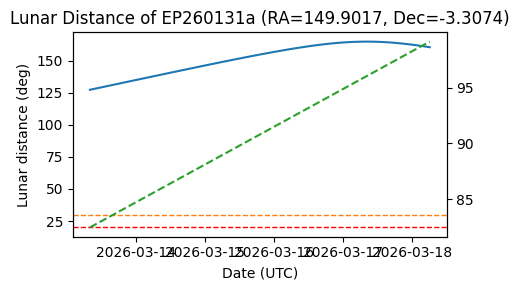

<Figure size 640x480 with 0 Axes>

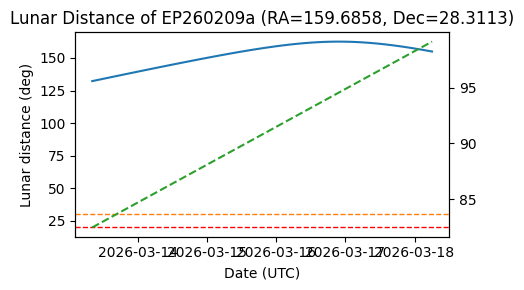

<Figure size 640x480 with 0 Axes>

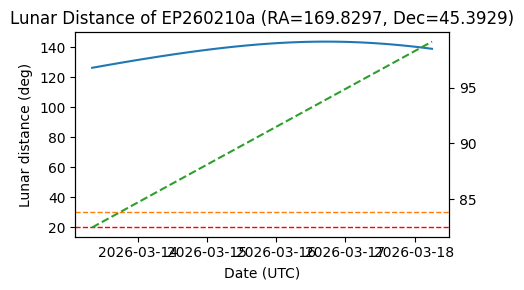

<Figure size 640x480 with 0 Axes>

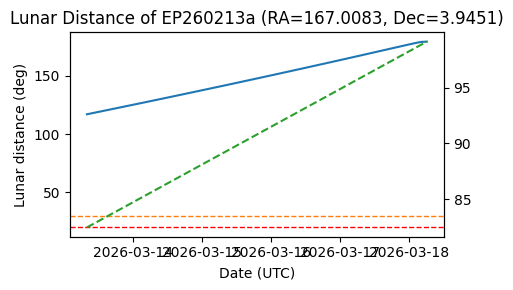

<Figure size 640x480 with 0 Axes>

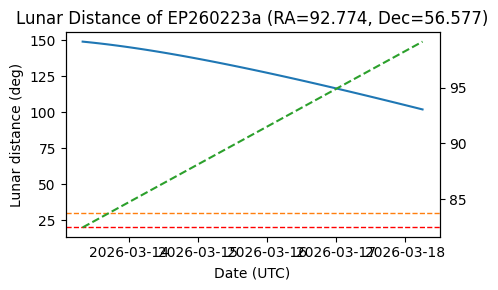

<Figure size 640x480 with 0 Axes>

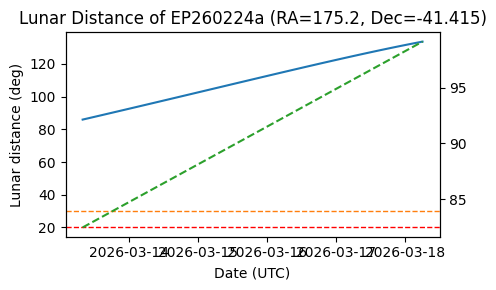

<Figure size 640x480 with 0 Axes>

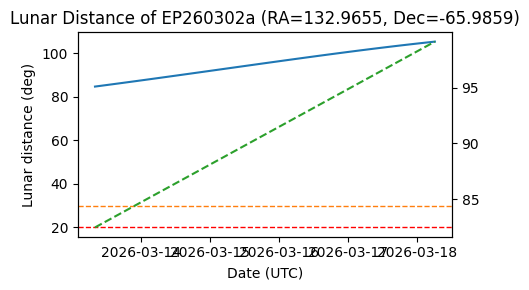

<Figure size 640x480 with 0 Axes>

In [4]:
#targets = ['EP260116a','EP251221a','EP251229a','EP260101a','EP260104a','EP260105a','EP260110a']
sources = Table.read("/home/liangrd/Follow_up/Candidates.csv")
targets = sources[sources['Priority']>1]['EP Name']
idx = np.isin(sources['EP Name'],targets)
ras, decs = list(sources['RA'][idx]), list(sources['Dec'][idx])

for target, ra, dec in zip(targets,ras,decs):
    plot_lunar_distance(ra,dec,step_hours=2,name=target,ndays=5)

In [4]:
(np.log10(0.8) + 8.184)/0.415

np.float64(19.486963824076973)